## Figure 2. Storm tracking examples for the B7 domain (Iowa).

In [13]:
#Packages:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd
import scrapbook as sb
import sys
import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.cm import ScalarMappable
from skimage import measure
from windrose import WindroseAxes
from scipy.interpolate import splprep, splev
import matplotlib.gridspec as gridspec

In [2]:
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [6]:
## Storm tracking parameters
morph_radius = 2 # radius for morph structure
high_treshold = 0.5 # threshold for high precipitation (in mm/hr)
storm_interval = '12H' # storm time interval for getting the most intese precipitation

## Reading control area and transposition domain shapefile
control_area_path = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Shapes/control_area_circle_79.0.shp'
transposition_domain_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Domains/Domain_58.shp"

# Read the storm catalog
#folder = run_folder +  '/Results/'+ scenario_name+'/StormCatalog/'
catalog_folder  = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_58.0_circle_10000km2/StormCatalog'


In [7]:
control_area = gpd.read_file(control_area_path)
transposition_domain = gpd.read_file(transposition_domain_path)
# Get the list of storm events from the catalog folder
domain_name = control_area_path.split('/')[-1].split('_')[3][:4]
event_list = os.listdir(catalog_folder)
event_list = [event for event in event_list if event.endswith('.nc')] ## filter only netcdf files

In [8]:
# create dictionary to store the results
storm_tracking_results = {}

# Iterate over each event in the event_list
event_list.sort()

for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

for storm_event in event_list:
    ds = xr.open_dataset(os.path.join(catalog_folder, storm_event)) # Load the dataset
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict, morph_radius=morph_radius, high_threshold=high_treshold)
    if int(event_dict['longest_duration']) <= 6:
        print(f"Skipping event {storm_event} due to short duration: {event_dict['longest_duration']} time steps.")
        continue
    continuos_storm(event_dict)
    storm_tracking_features(event_dict, ellipse_fit="Momentum")
    storm_tracking_results[storm_event] = event_dict # Store the results in the dictionary

IOWA_Domain.nc_storm_100_20020621.nc
The longest storm has a valid duration of 9 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2002-06-21T07:00:00.000000000 to 2002-06-21T15:00:00.000000000
Selected storm duration 9 hours
IOWA_Domain.nc_storm_101_20050811.nc
The longest storm has a valid duration of 15 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2005-08-11T09:00:00.000000000 to 2005-08-11T23:00:00.000000000
Selected storm duration 15 hours
IOWA_Domain.nc_storm_102_20040612.nc
The longest storm has a valid duration of 10 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2004-06-12T21:00:00.000000000 to 2004-06-13T06:00:00.000000000
Selected storm duration 10 hours
IOWA_Domain.nc_storm_103_20190630.nc
The longest storm has a valid duration of 8 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2019-06-30T20:00:00.000000000 to 2019-07-01

In [9]:
# removing empty storms events
storm_tracking_results = {k: v for k, v in storm_tracking_results.items() if v}

# list for storing the results
storm_mean_velocity = []
storm_mean_direction_vector = []
storm_mean_direction_weighted = []
storm_dir_variance = []
storm_mean_direction_lm = []
storm_intesity = []
storm_area = []
position=[]
start_time_list = []
end_time_list = []


# dictory to store the trajectories in the defined time window
storm_trajectories = {}
# Iterate over each storm event in the tracking results
for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    mean_p_ellipse = mean_precipitation_within_ellipse(storm)
    mean_p = pd.Series(mean_p_ellipse, index=storm['selected_storm_time_steps'].values)
    most_intense_interval = get_max_accumulated_value(mean_p, storm_interval)
    start_time_index = most_intense_interval[3] # start time index 
    end_time_index = most_intense_interval[4] # end time index
    if mean_p_ellipse.min() < 0:
        print(f"Warning: Negative mean precipitation values found in storm {storm_event}. Check the data.")
        continue
    # Getting the centroid coordinates for the start and end time
    x = storm['storm_prj_lon_cent_list'][start_time_index:end_time_index]
    y = storm['storm_prj_lat_cent_list'][start_time_index:end_time_index]

    # compute the length of the trajectory
    trajectory_length = compute_line_length(x, y)

    storm_trajectories[storm_event] = {
        'start_time_index': start_time_index,
        'end_time_index': end_time_index,
        'x_coords': x,
        'y_coords': y,
        'trajectory_length': trajectory_length,
        'mean_precipitation': mean_p_ellipse[start_time_index:end_time_index+1].mean(),
        'storm_id': int(storm_event.split('_storm_')[1].split('_')[0]),  # Extracting storm ID from the filename 
    }
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d,vd = mean_direction(x, y)
    wd, wv = mean_direction_weighted(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    storm_id = storm_event.split('_storm_')[1].split('_')[0]
    position.append(int(storm_id)) # storm ID
    storm_mean_direction_weighted.append(wd)
    storm_dir_variance.append(wv)
    start_time_list.append(storm['selected_storm_time_steps'][start_time_index].values)
    end_time_list.append(storm['selected_storm_time_steps'][end_time_index].values)
    storm_intesity.append(mean_p_ellipse[start_time_index:end_time_index+1].mean())
    storm_area.append(storm['selected_storm_area'][start_time_index:end_time_index+1].mean())
    
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['var_direction'] = vd
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm
    storm_tracking_results[storm_event]['mean_direction_weighted'] = wd
    storm_tracking_results[storm_event]['var_dir_weighted'] = wv
    storm_tracking_results[storm_event]['mean_precipitation'] = mean_p_ellipse[start_time_index:end_time_index+1].mean()
    storm_tracking_results[storm_event]['storm_area'] = storm['selected_storm_area'][start_time_index:end_time_index+1].mean()
    # Define the transformer for converting projected coordinates to geographic coordinates
transformer = Transformer.from_crs("EPSG:2163", "EPSG:4326", always_xy=True)

# Create a dictionary to store the geographic trajectories
geographic_trajectories = {}

# Iterate over each trajectory in storm_trajectories
for storm_event, traj in storm_trajectories.items():
    x_coords = traj['x_coords']
    y_coords = traj['y_coords']
    
    # Transform the coordinates
    lon_coords, lat_coords = transformer.transform(x_coords, y_coords)
    
    # Store the geographic coordinates in the dictionary
    geographic_trajectories[storm_event] = {
        'start_time_index': traj['start_time_index'],
        'end_time_index': traj['end_time_index'],
        'lon_coords': lon_coords,
        'lat_coords': lat_coords,
        'trajectory_length': traj['trajectory_length']
    }
#save the properties in dataframe
storm_properties = pd.DataFrame({
    'storm_id': position,
    'start_time': start_time_list,
    'end_time': end_time_list,
    'mean_velocity': storm_mean_velocity,
    'mean_direction_vector': storm_mean_direction_vector,
    'mean_direction_lm': storm_mean_direction_lm,
    'mean_direction_weighted': storm_mean_direction_weighted,
    'var_direction': storm_dir_variance,
    'storm_area': storm_area,
})
storm_properties.index = storm_properties['start_time']
storm_properties = storm_properties.sort_index()
df = pd.DataFrame.from_dict(storm_trajectories,orient='index')

def storm_time_steps(fig, subplot_spec, storm_tracking_results, storm_name, start_end, time_window):
    """
    Plots the storm precipitation, storm center, and fitted ellipse at a given time index.

    Parameters:
    - event_dict (dict): Dictionary containing storm data.
    - time_window (str): String of the selected time window for the trajectory.
    - start_end (tuple): Indexes values of the start and end time step of the most intensive time window
    """
    # Get the event dictionary for the specified storm name
    event_dict = storm_tracking_results[storm_name]
    
    # Get the shape of the figure using the time window
    time_window_options = ['6H', '9H', '12H', '16H', '24H']
    fig_shape = [(2,3), (3,3), (3,4), (4,4), (4,4)]  # shape of the figure
    dict_shape = dict(zip(time_window_options, fig_shape))  # dictionary of the shape
    
    rows, cols = dict_shape[time_window]

    # Create a grid of subplots inside the provided subplot_spec
    nested_gs = gridspec.GridSpecFromSubplotSpec(rows, cols, subplot_spec=subplot_spec, hspace=0.005, wspace=0.05)
    axes_list = []
    for i in range(rows * cols):
        ax = fig.add_subplot(nested_gs[i], projection=ccrs.PlateCarree())
        axes_list.append(ax)

    # Get the maximum and minimum values for the colorbar
    time_steps_window = range(start_end[0], start_end[1],1)
    t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0] + 1)]  # time list for plotting
    for time_index, ax in zip(time_steps_window, axes_list):
        if time_index >= event_dict['selected_storm'].shape[0]:
            break
        
        # Get the current precipitation array
        curr_prcp_array = event_dict['selected_storm'][time_index]
        # Set the threshold level
        cb_max = curr_prcp_array.flatten().max()
        cb_min = 0.2
        # Plot the projected precipitation data
        rain = ax.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], 
                             np.ma.masked_where(curr_prcp_array < 0.5, curr_prcp_array),
                             cmap='Blues', vmax=cb_max, vmin=cb_min)
        
        time_str = str(event_dict['selected_storm_time_steps'].values[time_index])

        # Plot the storm centroid
        ax.plot(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index], 'ro--', 
                label='storm center')

        # Plot the fitted ellipse
        ellipse_artist = Ellipse(
            xy=(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index]),
            width=event_dict['storm_record']['matplotlib_width(m)'][time_index] / 111000,  # horizontal axis
            height=event_dict['storm_record']['matplotlib_height(m)'][time_index] / 111000,  # vertical axis
            angle=event_dict['storm_record']['ellipse_angle (degree)'][time_index],
            edgecolor='red',
            fill=False,
            linewidth=2,
        )
        ax.add_artist(ellipse_artist)
        ax.text(
            0.98,
            0.02,
            t_list[time_index],
            fontsize=10,
            ha='right',
            va='bottom',
            transform=ax.transAxes
        )
    
    ## Set colorbar for all plots
    ## min and max values for the colorbar
    cb_max = event_dict['selected_storm'].flatten().max()
    cb_max = 20
    cb_min = 0.2
    n_storm = int(storm_name.split('_storm_')[1].split('_')[0])

    # Adjust layout and save the figure
    plt.tight_layout()

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Stormcatalog-analyzer/functions/storm_direction.py:186: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window = pd.to_timedelta(window)


In [10]:
def storm_track2(fig, sub_spec, storm_tracking_results, storm_name, storm_trajectories, panel_name='A'):

    start_time_index = storm_trajectories[storm_name]['start_time_index']
    end_time_index   = storm_trajectories[storm_name]['end_time_index']

    event_dict = storm_tracking_results[storm_name]
    n_storm = int(storm_name.split('_storm_')[1].split('_')[0])

    t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0] + 1)]

    acum_prcp = event_dict['selected_storm'][start_time_index:end_time_index].sum(axis=0)

    cb_max = float(acum_prcp.flatten().max())
    cb_min = 0.2

    # ---- nested layout ----
    nested_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=sub_spec,
        wspace=0.08,
        hspace=0.08,
        width_ratios=[1, 2],
        height_ratios=[1]
    )

    # ---- axes creation ----
    ax = [None, None]

    # placeholder axis for slot 0 (storm_time_steps will manage its own content)
    ax[0] = fig.add_subplot(nested_gs[:, 0], )
    ax[0].axis('off')

    # axis 2 spans both rows
    ax[1] = fig.add_subplot(nested_gs[:, 1], projection=ccrs.PlateCarree())

    # ----------------------------
    # 1) First plot: storm time steps
    # ----------------------------
    # Adjust the position of the plot to avoid overlapping with the vertical text
    pos0 = nested_gs[:, 0].get_position(fig).translated(0.05, 0)  # Shift the plot to the right
    ax[0].set_position(pos0)

    # Add the storm time steps plot
    storm_time_steps(
        fig, nested_gs[:, 0],
        storm_tracking_results=storm_tracking_results,
        storm_name=storm_name,
        start_end=(start_time_index, end_time_index),
        time_window='12H'
    )
    ax[0].text(
        0.03, 1, f'{panel_name}',
        transform=ax[0].transAxes,
        ha='left', va='top',
        fontsize=12, fontweight='bold', zorder=1,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1)
    )

    # Add vertical text with the storm name
    storm_n = storm_name.split('_')[3]
    storm_date = storm_name.split('_')[4]
    ax[0].text(
        -0.1, 0.5, 'Storm ' + storm_n + ' - ' + storm_date[:8],
        transform=ax[0].transAxes,
        ha='center', va='center',
        fontsize=10, rotation=90, fontweight='bold'
    )


    # ----------------------------
    # 2) Second plot: precipitation + centroid + ellipses
    # ----------------------------
    #rain = ax[1].pcolormesh(
    #    event_dict['lon_array'], event_dict['lat_array'],
    #    np.ma.masked_where(acum_prcp < cb_min, acum_prcp),
    #    cmap='Blues', vmax=cb_max, vmin=cb_min
    #)

    ax[1].plot(
        event_dict['storm_lon_cent'][start_time_index:end_time_index],
        event_dict['storm_lat_cent'][start_time_index:end_time_index],
        'ro--', label='Storm Centroid'
    )

    for lon, lat, label in zip(
        event_dict['storm_lon_cent'][start_time_index:end_time_index],
        event_dict['storm_lat_cent'][start_time_index:end_time_index],
        t_list[start_time_index:end_time_index]
    ):
        ax[1].text(lon, lat, label, fontsize=10, ha='right', va='bottom')

    for time_index in range(start_time_index, end_time_index):
        ellipse_artist = Ellipse(
            xy=(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index]),
            width=event_dict['storm_record']['matplotlib_width(m)'][time_index] / 111000,
            height=event_dict['storm_record']['matplotlib_height(m)'][time_index] / 111000,
            angle=event_dict['storm_record']['ellipse_angle (degree)'][time_index],
            edgecolor='lightcoral',
            fill=False,
            linewidth=1,
        )
        ax[1].add_artist(ellipse_artist)

    #ax[1].add_feature(cfeature.STATES, edgecolor='black', linewidth=1)

    lon_min = np.array(event_dict['storm_lon_cent'][start_time_index:end_time_index]).min() - 0.1
    lon_max = np.array(event_dict['storm_lon_cent'][start_time_index:end_time_index]).max() + 0.1
    lat_min = np.array(event_dict['storm_lat_cent'][start_time_index:end_time_index]).min() - 0.1
    lat_max = np.array(event_dict['storm_lat_cent'][start_time_index:end_time_index]).max() + 0.1

    bounding_box = Rectangle(
        (lon_min , lat_min ),
        lon_max - lon_min ,
        lat_max - lat_min ,
        linewidth=2, edgecolor='green', facecolor='none', linestyle='--'
    )
    ax[1].add_patch(bounding_box)

    # Set the extent of the map to focus on the storm area
    x_max = np.array(event_dict['storm_lon_cent'][start_time_index:end_time_index]).max() + 0.5
    x_min = np.array(event_dict['storm_lon_cent'][start_time_index:end_time_index]).min() - 0.5
    y_max = np.array(event_dict['storm_lat_cent'][start_time_index:end_time_index]).max() + 0.5
    y_min = np.array(event_dict['storm_lat_cent'][start_time_index:end_time_index]).min() - 0.5
    
    ax[1].set_extent([x_min, x_max, y_min, y_max], crs=ccrs.PlateCarree())
    ax[1].set_aspect('equal', adjustable='box')
    gl1 = ax[1].gridlines(draw_labels=False, linestyle='--')

    mean_track_direction = storm_tracking_results[storm_name]['mean_direction_weighted']

    x = np.array(event_dict['storm_lon_cent'][start_time_index:end_time_index])
    y = np.array(event_dict['storm_lat_cent'][start_time_index:end_time_index])
    xa, ya = x.mean(), y.mean()

    theta = np.radians(mean_track_direction)
    cx, sy = np.cos(theta), np.sin(theta)

    def bound_along(dir_comp, low, mid, high):
        if dir_comp == 0:
            return np.inf
        pos = (high - mid) / abs(dir_comp)
        neg = (mid - low)  / abs(dir_comp)
        return min(pos, neg)

    tx = bound_along(cx, x.min(), xa, x.max())
    ty = bound_along(sy, y.min(), ya, y.max())
    half_len = min(tx, ty)

    u = cx * (2 * half_len)
    v = sy * (2 * half_len)

    ax[1].quiver(
        xa, ya, u, v,
        angles='xy', scale_units='xy', pivot='middle', scale=1,
        color='blue', label='Mean Direction',
        transform=ccrs.PlateCarree()
    )
    ax[1].legend(loc='upper right', fontsize=8)

    # ----------------------------
    # Layout control
    # ----------------------------
    fig.subplots_adjust(top=0.92)

    # ---- lock positions to GridSpec slots (FIXED sizes) ----
    pos0 = nested_gs[:, 0].get_position(fig)
    pos1 = nested_gs[:, 1].get_position(fig)

    ax[0].set_position(pos0)
    ax[1].set_position(pos1)

    # add text for annotation for storm direction and angular variance
    mean_direction = storm_tracking_results[storm_name]['mean_direction_weighted']
    angular_variance = storm_tracking_results[storm_name]['var_dir_weighted']
    mean_speed = storm_tracking_results[storm_name]['mean_velocity']


    # Add text box in axis 2 (lower-right corner)
    ax[1].text(
        0.97, 0.03,
        f'Storm direction: {mean_direction:.1f}°\nAngular variance: {angular_variance:.2f} \nMean speed: {mean_speed:.2f} m/s\n Storm area: {storm_tracking_results[storm_name]["storm_area"]:.2f} km²',

        transform=ax[1].transAxes,
        ha='right', va='bottom',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1, alpha=0.8)
    )

    # ---- stable outline around the 2 panels ----
    # Expand a bit so the outline does not sit on top of axes content
    bb = Bbox.union([pos0, pos1]).expanded(1.02, 1.05)

    outline = Rectangle(
        (bb.x0, bb.y0),
        bb.width, bb.height,
        transform=fig.transFigure,
        fill=False, linewidth=1.5, edgecolor='black',
        zorder=3, clip_on=False
    )
    fig.add_artist(outline)

    return ax

/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_55127/1585249378.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_55127/1585249378.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_55127/1585249378.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_55127/1585249378.py:190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


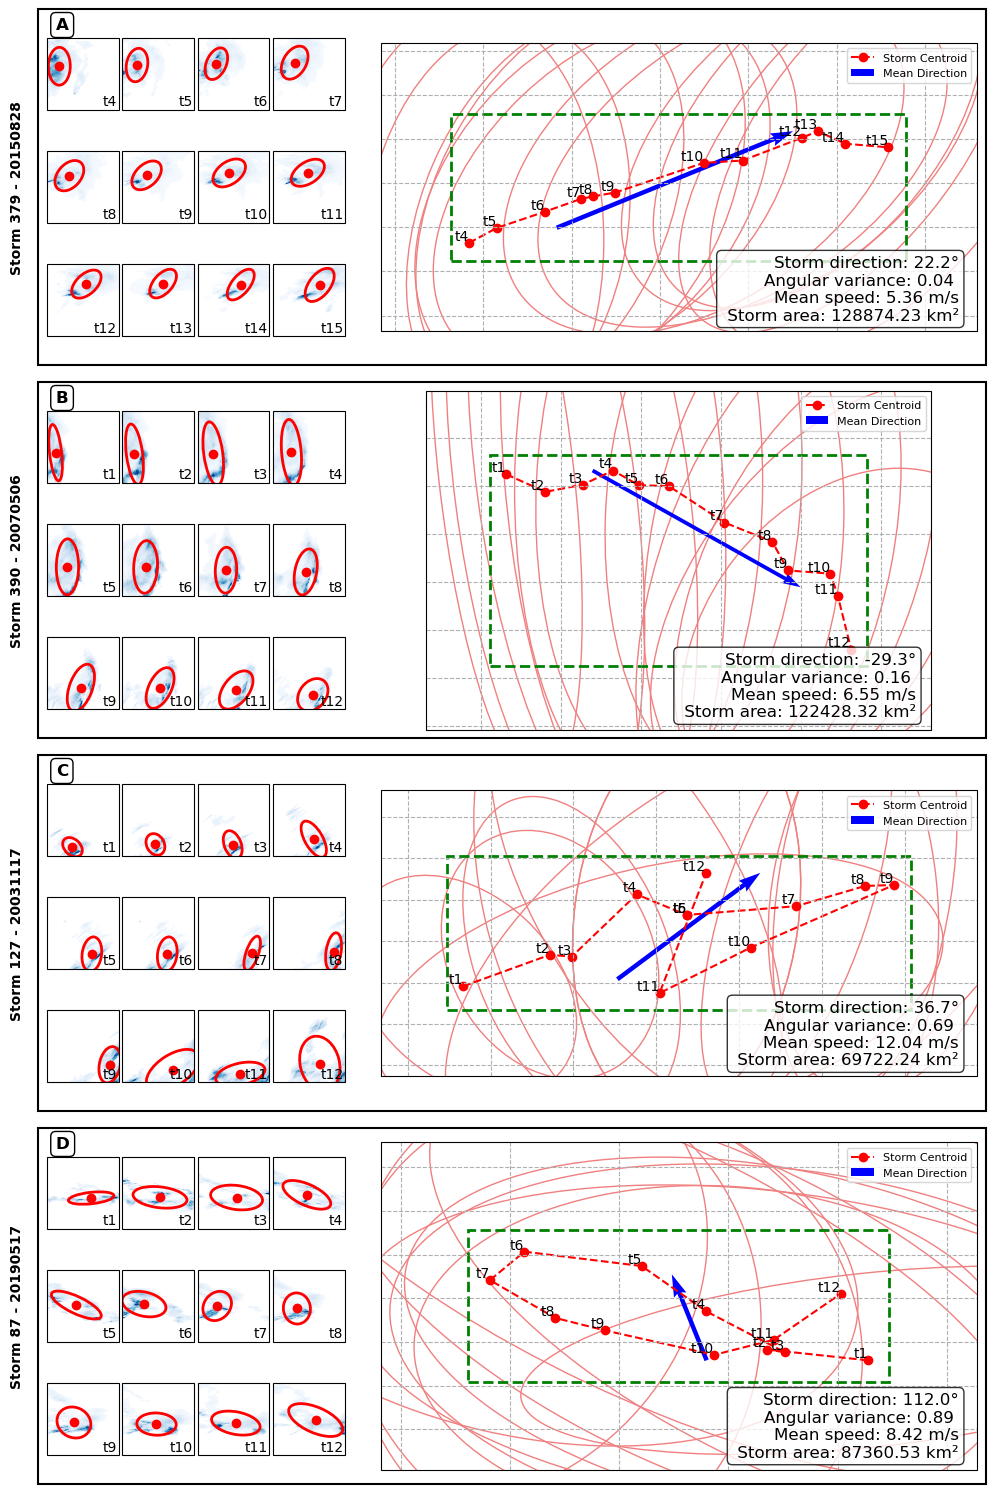

In [14]:
fig = plt.figure(figsize=(12, 18))
gs = gridspec.GridSpec(4, 1, figure=fig, hspace=0.1)
name = [storm for storm in storm_tracking_results.keys() if '_379_' in storm][0]
track_plot = storm_track2(fig, gs[0,0],storm_tracking_results=storm_tracking_results, storm_name=name, storm_trajectories=storm_trajectories, panel_name='A')
name2 = [storm for storm in storm_tracking_results.keys() if '_390_' in storm][0]
track_plot = storm_track2(fig, gs[1,0],storm_tracking_results=storm_tracking_results, storm_name=name2, storm_trajectories=storm_trajectories, panel_name='B')
name3 = [storm for storm in storm_tracking_results.keys() if '_127_' in storm][0]
track_plot = storm_track2(fig, gs[2,0],storm_tracking_results=storm_tracking_results, storm_name=name3, storm_trajectories=storm_trajectories, panel_name='C')
name4 = [storm for storm in storm_tracking_results.keys() if '_87_' in storm][0]
track_plot = storm_track2(fig, gs[3,0],storm_tracking_results=storm_tracking_results, storm_name=name4, storm_trajectories=storm_trajectories, panel_name='D')
